In [1]:
import pandas as pd
import numpy as np

# Set seed for reproducible random generation
np.random.seed(42)
n_rows = 1200

# Generate realistic columns
dates = pd.date_range(start="2026-01-01", end="2026-06-30", periods=n_rows)
products = ['Laptop', 'Wireless Mouse', 'Mechanical Keyboard', '4K Monitor', 'USB-C Hub', 
            'Gaming Headset', 'Desk Mat', 'Webcam', 'External SSD', 'Ergonomic Chair']
categories = ['Electronics', 'Accessories', 'Accessories', 'Electronics', 'Accessories', 
              'Audio', 'Office', 'Electronics', 'Storage', 'Furniture']
regions = ['North', 'East', 'South', 'West']

# Create mapping for products to categories
prod_to_cat = dict(zip(products, categories))

random_products = np.random.choice(products, size=n_rows)
random_categories = [prod_to_cat[p] for p in random_products]
random_regions = np.random.choice(regions, size=n_rows)
random_units = np.random.randint(1, 10, size=n_rows)

# Generate prices matching the product categories
prices_map = {'Laptop': 120000, 'Wireless Mouse': 2500, 'Mechanical Keyboard': 8000, 
              '4K Monitor': 45000, 'USB-C Hub': 3500, 'Gaming Headset': 7500, 
              'Desk Mat': 1500, 'Webcam': 6000, 'External SSD': 15000, 'Ergonomic Chair': 25000}
random_amounts = [prices_map[p] * u for p, u in zip(random_products, random_units)]

# Generate Customer IDs and Invoice Numbers
customer_ids = [f"CUST-{np.random.randint(1000, 1150)}" for _ in range(n_rows)]
invoice_nos = [f"INV-{np.random.randint(50000, 52000)}" for _ in range(n_rows)]

# Assemble raw DataFrame
raw_df = pd.DataFrame({
    'InvoiceNo': invoice_nos,
    'CustomerID': customer_ids,
    'Date': dates,
    'Product': random_products,
    'Category': random_categories,
    'Region': random_regions,
    'Units': random_units,
    'Amount': random_amounts
})

# Introduce messy data on purpose (missing values and duplicates)
raw_df.loc[np.random.choice(raw_df.index, size=30, replace=False), 'Amount'] = np.nan
raw_df.loc[np.random.choice(raw_df.index, size=20, replace=False), 'Date'] = np.nan
raw_df = pd.concat([raw_df, raw_df.sample(25)], ignore_index=True)

# Save to your local directory
raw_df.to_csv('sales_data.csv', index=False)
print("✅ Success! 'sales_data.csv' has been generated in your workspace folder.")

✅ Success! 'sales_data.csv' has been generated in your workspace folder.


In [2]:
# 1. Load the data
df = pd.read_csv('sales_data.csv')
print("--- RAW DATA SHAPE ---")
print(df.shape)  # Show starting shape

# 2. Inspect original null counts
print("\n--- MISSING VALUES BEFORE CLEANING ---")
print(df.isnull().sum())

# 3. Clean the data (Drop Nulls and Duplicates)
df = df.dropna()
df = df.drop_duplicates()

# 4. Standardize dates
df['Date'] = pd.to_datetime(df['Date'])

print("\n--- CLEANED DATA SHAPE ---")
print(df.shape)  # Missing and duplicate rows are now cleared!

--- RAW DATA SHAPE ---
(1225, 8)

--- MISSING VALUES BEFORE CLEANING ---
InvoiceNo      0
CustomerID     0
Date          20
Product        0
Category       0
Region         0
Units          0
Amount        31
dtype: int64

--- CLEANED DATA SHAPE ---
(1150, 8)


In [3]:
# Figure 1: Top 10 Products (Bar Chart)
plt.figure(figsize=(10, 5))
top_products = df.groupby('Product')['Amount'].sum().nlargest(10)
top_products.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue (Rs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Figure 2: Monthly Sales Trend (Line Plot)
plt.figure(figsize=(10, 5))
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
monthly_sales.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Figure 3: Sales Distribution by Region (Pie Chart)
plt.figure(figsize=(7, 7))
by_region = df.groupby('Region')['Amount'].sum()
by_region.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], startangle=140)
plt.title('Sales Distribution by Region')
plt.ylabel('') # Hides default 'Amount' text on the side
plt.show()

NameError: name 'plt' is not defined

In [4]:
import pandas as pd

# 1. Reload data to make sure 'df' is active in this cell
df = pd.read_csv('sales_data.csv')
df = df.dropna()
df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'])

# 2. Corrected Category Comparison (from Step 5 of the guide)
by_category = df.groupby('Category').agg({
    'Amount': 'sum',
    'Units': 'sum'
})

print("--- CATEGORY COMPARISON ---")
print(by_category)
print("\n" + "="*50)

# 3. Fully Corrected Report Script (fixing all brackets and braces from the PDF guide)
total_records = len(df)
date_min = df['Date'].min().strftime('%Y-%m-%d')
date_max = df['Date'].max().strftime('%Y-%m-%d')
total_revenue = df['Amount'].sum()
avg_sale = df['Amount'].mean()
median_sale = df['Amount'].median()

# Find top 5 products
top_5_products = df.groupby('Product')['Amount'].sum().nlargest(5)

# Find the best performing month
best_month = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum().idxmax()

# Format the report text cleanly
report_content = f"""==================================================
              SALES ANALYSIS REPORT             
==================================================
Total Records: {total_records}
Date Range: {date_min} to {date_max}
Total Revenue: Rs {total_revenue:,.0f}
Average Sale: Rs {avg_sale:,.0f}
Median Sale: Rs {median_sale:,.0f}

Top 5 Products:
{top_5_products.to_string()}

Best Month:
{best_month}
=================================================="""

# Print the report output to your screen
print(report_content)

# Write it directly to your local file report.txt
with open("report.txt", "w") as f:
    f.write(report_content)

print("\n💾 'report.txt' has been generated and saved successfully!")

--- CATEGORY COMPARISON ---
                  Amount  Units
Category                       
Accessories    8068000.0   1687
Audio          4290000.0    572
Electronics  107715000.0   1746
Furniture     15375000.0    615
Office          855000.0    570
Storage        7620000.0    508

              SALES ANALYSIS REPORT             
Total Records: 1150
Date Range: 2026-01-01 to 2026-06-30
Total Revenue: Rs 143,923,000
Average Sale: Rs 125,150
Median Sale: Rs 40,000

Top 5 Products:
Product
Laptop                 80640000.0
4K Monitor             23805000.0
Ergonomic Chair        15375000.0
External SSD            7620000.0
Mechanical Keyboard     4776000.0

Best Month:
2026-03

💾 'report.txt' has been generated and saved successfully!


In [5]:
# Figure 1: Top 10 Products (Bar Chart)
plt.figure(figsize=(10, 5))
top_products = df.groupby('Product')['Amount'].sum().nlargest(10)
top_products.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue (Rs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Figure 2: Monthly Sales Trend (Line Plot)
plt.figure(figsize=(10, 5))
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
monthly_sales.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Figure 3: Sales Distribution by Region (Pie Chart)
plt.figure(figsize=(7, 7))
by_region = df.groupby('Region')['Amount'].sum()
by_region.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], startangle=140)
plt.title('Sales Distribution by Region')
plt.ylabel('') # Hides default 'Amount' text on the side
plt.show()

NameError: name 'plt' is not defined

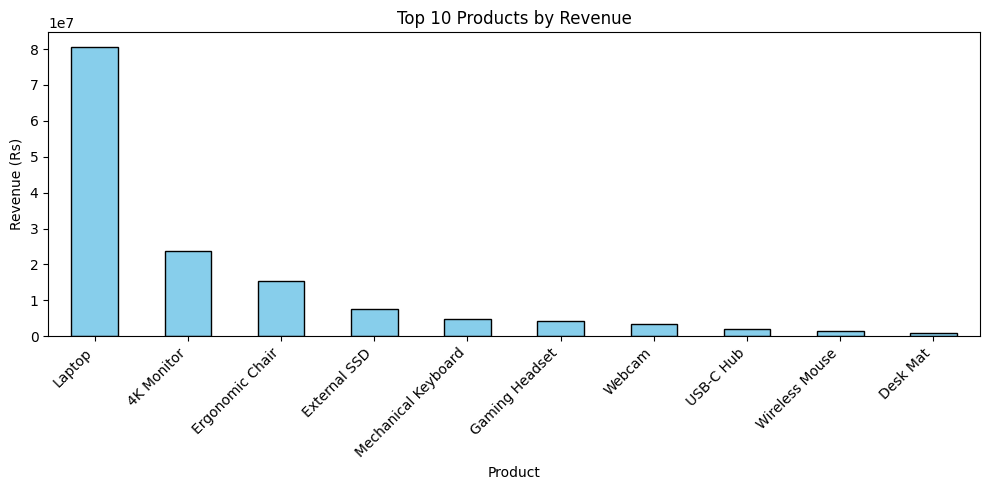

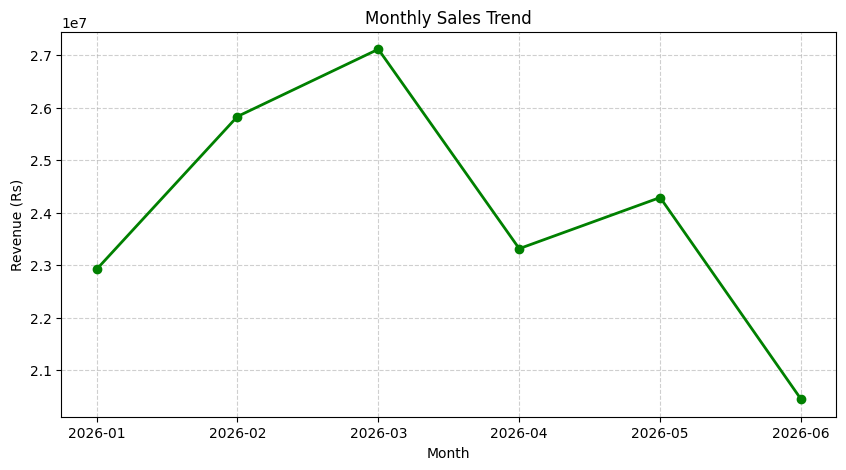

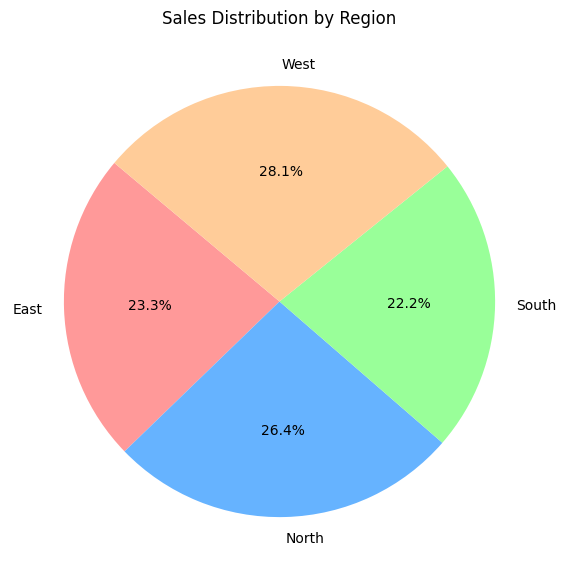

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure the cleaned data is loaded in this notebook session
df = pd.read_csv('sales_data.csv')
df = df.dropna()
df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'])

# ==================================================
# Figure 1: Top 10 Products (Bar Chart)
# ==================================================
plt.figure(figsize=(10, 5))
top_products = df.groupby('Product')['Amount'].sum().nlargest(10)
top_products.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue (Rs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==================================================
# Figure 2: Monthly Sales Trend (Line Plot)
# ==================================================
plt.figure(figsize=(10, 5))
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
# Converting Period index to string representation for clean plotting
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==================================================
# Figure 3: Sales Distribution by Region (Pie Chart)
# ==================================================
plt.figure(figsize=(7, 7))
by_region = df.groupby('Region')['Amount'].sum()
by_region.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], startangle=140)
plt.title('Sales Distribution by Region')
plt.ylabel('')  # Hides default 'Amount' text on the side
plt.show()

In [7]:
import pandas as pd

# 1. Reload and clean to keep state safe
df = pd.read_csv('sales_data.csv')
df = df.dropna()
df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'])

# 2. Corrected Category Comparison (resolving typos in the guide)
by_category = df.groupby('Category').agg({
    'Amount': 'sum',
    'Units': 'sum'
})

print("--- CATEGORY COMPARISON ---")
print(by_category)
print("\n" + "="*50)

# 3. Securely calculate variables for the report (cleaning up guide's syntax errors)
total_records = len(df)
date_min = df['Date'].min().strftime('%Y-%m-%d')
date_max = df['Date'].max().strftime('%Y-%m-%d')
total_revenue = df['Amount'].sum()
avg_sale = df['Amount'].mean()
median_sale = df['Amount'].median()

# Find top 5 products and best performing month
top_5_products = df.groupby('Product')['Amount'].sum().nlargest(5)
best_month = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum().idxmax()

# Format the clean report content
report_content = f"""==================================================
              SALES ANALYSIS REPORT             
==================================================
Total Records: {total_records}
Date Range: {date_min} to {date_max}
Total Revenue: Rs {total_revenue:,.0f}
Average Sale: Rs {avg_sale:,.0f}
Median Sale: Rs {median_sale:,.0f}

Top 5 Products:
{top_5_products.to_string()}

Best Month:
{best_month}
==================================================="""

# Print report to screen
print(report_content)

# Automatically write it to your required report.txt file
with open("report.txt", "w") as f:
    f.write(report_content)

print("\n💾 Success! 'report.txt' has been generated and saved to your folder.")

--- CATEGORY COMPARISON ---
                  Amount  Units
Category                       
Accessories    8068000.0   1687
Audio          4290000.0    572
Electronics  107715000.0   1746
Furniture     15375000.0    615
Office          855000.0    570
Storage        7620000.0    508

              SALES ANALYSIS REPORT             
Total Records: 1150
Date Range: 2026-01-01 to 2026-06-30
Total Revenue: Rs 143,923,000
Average Sale: Rs 125,150
Median Sale: Rs 40,000

Top 5 Products:
Product
Laptop                 80640000.0
4K Monitor             23805000.0
Ergonomic Chair        15375000.0
External SSD            7620000.0
Mechanical Keyboard     4776000.0

Best Month:
2026-03

💾 Success! 'report.txt' has been generated and saved to your folder.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the raw generated dataset
df = pd.read_csv('sales_data.csv')

# 2. Step 1: Initial Exploratory Checks (from Page 2 of the Guide)
print("--- FIRST 5 ROWS ---")
print(df.head()) # [cite: 100]

print("\n--- DATASET SHAPE (Rows, Columns) ---")
print(df.shape) # [cite: 102]

print("\n--- DATASET INFO ---")
print(df.info()) # [cite: 103]

print("\n--- INITIAL DESCRIPTIVE STATISTICS ---")
print(df.describe()) # [cite: 104]

print("\n--- MISSING VALUES BEFORE CLEANING ---")
print(df.isnull().sum()) # [cite: 109]

print("\n--- PRODUCT VALUE COUNTS (Category Balance Check) ---")
print(df['Product'].value_counts()) # [cite: 123]

--- FIRST 5 ROWS ---
   InvoiceNo CustomerID                           Date     Product  \
0  INV-50269  CUST-1052  2026-01-01 00:00:00.000000000    Desk Mat   
1  INV-51630  CUST-1038  2026-01-01 03:36:10.809007506  4K Monitor   
2  INV-50309  CUST-1064  2026-01-01 07:12:21.618015012      Webcam   
3  INV-51155  CUST-1144  2026-01-01 10:48:32.427022518   USB-C Hub   
4  INV-51574  CUST-1012  2026-01-01 14:24:43.236030025    Desk Mat   

      Category Region  Units    Amount  
0       Office  North      8   12000.0  
1  Electronics   East      4  180000.0  
2  Electronics   East      4   24000.0  
3  Accessories   West      4   14000.0  
4       Office  South      6    9000.0  

--- DATASET SHAPE (Rows, Columns) ---
(1225, 8)

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1225 entries, 0 to 1224
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   InvoiceNo   1225 non-null   object 
 1   Custome

In [9]:
# 3. Clean the dataset
df = df.dropna() # [cite: 110]
df = df.drop_duplicates() # [cite: 113]
df['Date'] = pd.to_datetime(df['Date']) # [cite: 115]

print("Data cleaning complete. Cleaned dataset shape:", df.shape)

Data cleaning complete. Cleaned dataset shape: (1150, 8)


In [10]:
# 1. Calculate Descriptive Statistics (with Standard Deviation added!)
total_records = len(df) # [cite: 179]
date_min = df['Date'].min().strftime('%Y-%m-%d') # [cite: 180]
date_max = df['Date'].max().strftime('%Y-%m-%d') # [cite: 181]
total_revenue = df['Amount'].sum() # [cite: 120]
avg_sale = df['Amount'].mean() # [cite: 120]
median_sale = df['Amount'].median() # 
std_sale = df['Amount'].std() # 

# 2. Run Regional and Category Aggregations
by_region = df.groupby('Region')['Amount'].sum() # [cite: 156]
by_category = df.groupby('Category').agg({
    'Amount': 'sum',
    'Units': 'sum' # [cite: 165]
}) # [cite: 162]

# Find top 5 products
top_5_products = df.groupby('Product')['Amount'].sum().nlargest(5) # [cite: 186]

# Find the best performing month
best_month = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum().idxmax() # [cite: 189]

# 3. Generate the Final Report Content containing all stats
report_content = f"""==================================================
              SALES ANALYSIS REPORT             
==================================================
Total Records: {total_records}
Date Range: {date_min} to {date_max}
Total Revenue: Rs {total_revenue:,.0f}
Average Sale: Rs {avg_sale:,.0f}
Median Sale: Rs {median_sale:,.0f}
Std Dev: Rs {std_sale:,.0f}

--------------------------------------------------
Category Comparison:
--------------------------------------------------
{by_category.to_string()}

--------------------------------------------------
Top 5 Products:
--------------------------------------------------
{top_5_products.to_string()}

Best Month: {best_month}
=================================================="""

# Print the report output to your screen
print(report_content)

# Write the report directly to report.txt
with open("report.txt", "w") as f:
    f.write(report_content)

print("\nSuccess! 'report.txt' has been generated and saved with Standard Deviation.")

              SALES ANALYSIS REPORT             
Total Records: 1150
Date Range: 2026-01-01 to 2026-06-30
Total Revenue: Rs 143,923,000
Average Sale: Rs 125,150
Median Sale: Rs 40,000
Std Dev: Rs 213,104

--------------------------------------------------
Category Comparison:
--------------------------------------------------
                  Amount  Units
Category                       
Accessories    8068000.0   1687
Audio          4290000.0    572
Electronics  107715000.0   1746
Furniture     15375000.0    615
Office          855000.0    570
Storage        7620000.0    508

--------------------------------------------------
Top 5 Products:
--------------------------------------------------
Product
Laptop                 80640000.0
4K Monitor             23805000.0
Ergonomic Chair        15375000.0
External SSD            7620000.0
Mechanical Keyboard     4776000.0

Best Month: 2026-03

Success! 'report.txt' has been generated and saved with Standard Deviation.


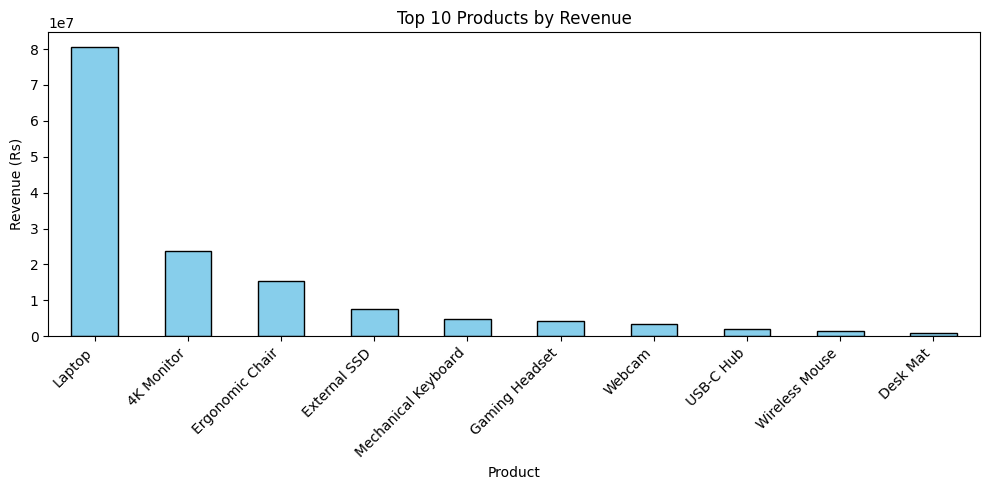

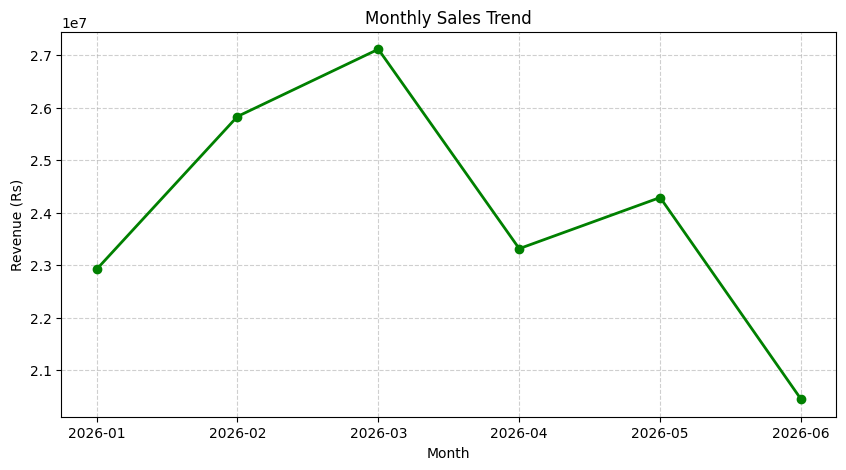

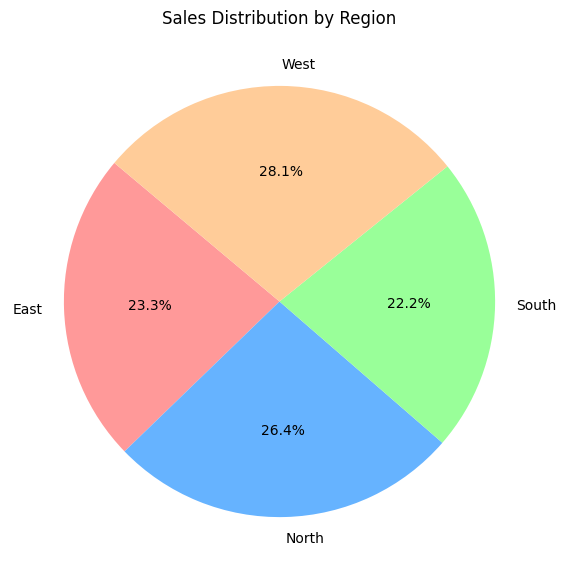

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure the cleaned data is loaded in this notebook session
df = pd.read_csv('sales_data.csv')
df = df.dropna()
df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'])

# ==================================================
# Figure 1: Top 10 Products (Bar Chart)
# ==================================================
plt.figure(figsize=(10, 5))
top_products = df.groupby('Product')['Amount'].sum().nlargest(10)
top_products.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue (Rs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==================================================
# Figure 2: Monthly Sales Trend (Line Plot)
# ==================================================
plt.figure(figsize=(10, 5))
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
# Converting Period index to string representation for clean plotting
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==================================================
# Figure 3: Sales Distribution by Region (Pie Chart)
# ==================================================
plt.figure(figsize=(7, 7))
by_region = df.groupby('Region')['Amount'].sum()
by_region.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], startangle=140)
plt.title('Sales Distribution by Region')
plt.ylabel('')  # Hides default 'Amount' text on the side
plt.show()